In [23]:
import polars as pl
import torch
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
from amaretto_mlp import *
from utils_b import *
from autoencoder import *
from model import *
from visualization import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
pl.Config.set_tbl_cols(150) 

polars.config.Config

## Load Data

In [3]:
df = pl.read_parquet("amaretto_transformed_scaled.pq")
df = df.with_columns(((pl.col('hour') >= 2) & (pl.col('hour') < 5)).alias('unusual_hour'))
df_train, df_val, df_test = split_data(df)

#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime']
#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute']
columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute', 'day_of_month_cos', 'minute_cos', 'day_of_month_sin', 'minute_sin']


target_column = 'Anomaly_bin'
y_train = df_train.select(target_column).to_numpy().flatten()
y_train_anomalies = df_train.select('Anomaly').to_numpy().flatten()
df_train = df_train.drop(columns_to_drop)
X_train = df_train.to_numpy()
y_val = df_val.select(target_column).to_numpy().flatten()
X_val = df_val.drop(columns_to_drop).to_numpy()
y_test = df_test.select(target_column).to_numpy().flatten()
y_test_anomalies = df_test.select('Anomaly').to_numpy().flatten()

X_test = df_test.drop(columns_to_drop).to_numpy()

train_dataset = AmarettoDataset(X_train, y_train)
val_dataset = AmarettoDataset(X_val, y_val)
test_dataset = AmarettoDataset(X_test, y_test)
feature_names = df_train.columns
print(X_train.shape)
print(X_test.shape)

(24451934, 118)
(2765755, 118)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=512, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=256, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, num_workers=2)
input_dim = X_train.shape[1]
df_train, df_val, df_test = split_data(df)
print(len(train_loader))

47758


## Train Model

In [5]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([  0.5014, 180.1141])

In [6]:
model = ProtoPNet(input_dim, hidden_layers=[64, 64], num_prototypes=20, num_classes=2, latent_dim=16)

In [7]:
model

ProtoPNet(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=118, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (proto_layer): PrototypeLayer()
  (last_layer): Linear(in_features=20, out_features=2, bias=False)
)

In [ ]:
model.proto_layer.prototypes

In [9]:
train_protopnet(model, train_loader, val_loader, epochs=6, lr=0.0001, class_weights=class_weights, lambda_clst=0.8, lambda_sep=0.08)

tensor([  0.5014, 180.1141])

Epoch 1/6


Epoch 1/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.6853
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.32696054739394065
Phase 3 - Last Layer Optimization Completed
Epoch 1: Val Loss = 0.1972
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.50      0.83      0.63      6708

    accuracy                           1.00   2486401
   macro avg       0.75      0.92      0.81   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.8127

Epoch 2/6


Epoch 2/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -0.7064
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.14124392329383953
Phase 3 - Last Layer Optimization Completed
Epoch 2: Val Loss = 0.1203
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.71      0.89      0.79      6708

    accuracy                           1.00   2486401
   macro avg       0.85      0.95      0.89   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.8949

Epoch 3/6


...

Phase 1 - Training Loss: -1.5990
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.17678830942778845
Phase 3 - Last Layer Optimization Completed
Epoch 4: Val Loss = 0.1339
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.80      0.89      0.84      6708

    accuracy                           1.00   2486401
   macro avg       0.90      0.94      0.92   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9215

Epoch 5/6


Epoch 5/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -2.0200
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.16050039787736528
Phase 3 - Last Layer Optimization Completed
Epoch 5: Val Loss = 0.1185
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.75      0.90      0.82      6708

    accuracy                           1.00   2486401
   macro avg       0.88      0.95      0.91   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9105

Epoch 6/6


Epoch 6/6 [Training]:   0%|          | 0/47758 [00:00<?, ?it/s]

Phase 1 - Training Loss: -2.4570
Phase 2 - Prototype Projection Completed
Epoch 1/1, Loss: 0.1296038314008334
Phase 3 - Last Layer Optimization Completed
Epoch 6: Val Loss = 0.1284
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.76      0.90      0.83      6708

    accuracy                           1.00   2486401
   macro avg       0.88      0.95      0.91   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.9125


## Results

In [12]:
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    z_test, distances, y_logits = model(X_test_tensor)
    y_probs_test = F.softmax(y_logits, dim=1)
    y_pred_test = torch.argmax(y_probs_test, dim=1)
y_pred_test = y_pred_test.cpu().numpy()
y_probs_test = y_probs_test.cpu().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()
print(z_test.shape)
print(distances.shape)

(2765755,)
(2765755, 16)
torch.Size([2765755, 20])


In [14]:
print(classification_report(y_test, y_pred_test, digits=4))


              precision    recall  f1-score   support

           0     0.9998    0.9990    0.9994   2759074
           1     0.6975    0.9267    0.7959      6681

    accuracy                         0.9989   2765755
   macro avg     0.8487    0.9628    0.8977   2765755
weighted avg     0.9991    0.9989    0.9989   2765755



In [15]:
print(confusion_matrix(y_test, y_pred_test))


[[2756389    2685]
 [    490    6191]]


In [16]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_test, y_test, n_samples=100000, anomaly_ratio=0.3)
y_pred_sampled = y_pred_test[selected_indices]
y_test_anomalies_sampled = y_test_anomalies[selected_indices]
print(z_sampled.shape)

[6681]
70000
2759074
70000
(76681, 16)


In [17]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(76681, 2)

In [18]:
prototypes = model.proto_layer.prototypes.detach().cpu().numpy()
prototype_embedding = reducer.transform(prototypes) 
prototype_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(20, 2)

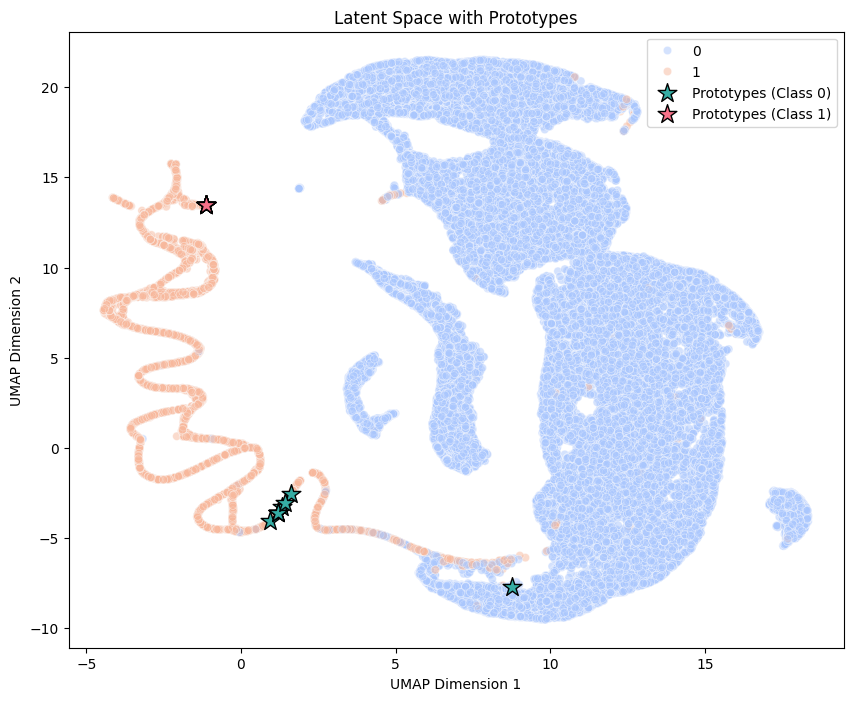

In [22]:
prototype_labels = model.proto_layer.prototype_labels
unique_proto_classes = np.unique(prototype_labels)  # Get unique classes
num_classes = len(unique_proto_classes)

# Assign different colors for different prototype classes
prototype_colors = sns.color_palette("husl", num_classes)  # Unique colors per class
proto_class_to_color = {cls: prototype_colors[-(i + 1)] for i, cls in enumerate(unique_proto_classes)}

# Create figure
plt.figure(figsize=(10, 8))

# Plot latent space data points
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_true_sampled, alpha=0.5, palette="coolwarm")

# Plot prototypes with different colors based on class
for proto_class in unique_proto_classes:
    class_mask = prototype_labels == proto_class  # Select prototypes of the same class
    plt.scatter(prototype_embedding[class_mask, 0], 
                prototype_embedding[class_mask, 1], 
                c=[proto_class_to_color[proto_class]],  # Assign color
                marker='*', 
                s=200, 
                edgecolors='black', 
                label=f'Prototypes (Class {proto_class})')

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("Latent Space with Prototypes")

plt.legend()
plt.show()

In [25]:
adjusted_rand_score(y_test, y_pred_test)

0.7944295104838559

In [21]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    z_train = model.encoder(X_train_tensor)
    prototypes = model.proto_layer.prototypes.detach()

# Compute L2 distances between prototypes and training latent space
dists = torch.cdist(prototypes, z_train)  # Shape: (num_prototypes, num_train_samples)

# Find closest training point for each prototype
closest_indices = torch.argmin(dists, dim=1)
closest_points = z_train[closest_indices]

distances = torch.min(dists, dim=1)[0]

for i, dist in enumerate(distances):
    print(f"Prototype {i}: Closest training point at index {closest_indices[i]}, Distance: {dist.item():.4f}")

Prototype 0: Closest training point at index 300, Distance: 0.0020
Prototype 1: Closest training point at index 582017, Distance: 0.0000
Prototype 2: Closest training point at index 300, Distance: 0.0020
Prototype 3: Closest training point at index 582017, Distance: 0.0000
Prototype 4: Closest training point at index 2294547, Distance: 0.0000
Prototype 5: Closest training point at index 582017, Distance: 0.0000
Prototype 6: Closest training point at index 300, Distance: 0.0020
Prototype 7: Closest training point at index 582017, Distance: 0.0000
Prototype 8: Closest training point at index 134084, Distance: 0.0000
Prototype 9: Closest training point at index 582017, Distance: 0.0000
Prototype 10: Closest training point at index 14231412, Distance: 0.0000
Prototype 11: Closest training point at index 582017, Distance: 0.0000
Prototype 12: Closest training point at index 300, Distance: 0.0020
Prototype 13: Closest training point at index 582017, Distance: 0.0000
Prototype 14: Closest tra